# 🌊 Load CMIP6 Data with Intake ESM

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Search** the Pangeo CMIP6 cloud catalog for a variable, experiment, and table of interest using `intake-esm`.
2. **Load** multi-model Zarr archives into lazy xarray/Dask datasets without downloading files.
3. **Inspect** dataset dimensions, coordinates, and CF metadata attributes.
4. **Visualise** a 2-D ocean field with `matplotlib` / `cartopy`.
5. **Plot** a continuous historical + SSP5-8.5 time series at a fixed ocean location using `.sel()` and lazy Dask evaluation.

## 📋 Prerequisites

| Topic | Where to learn |
|---|---|
| Python basics | any intro Python course |
| xarray fundamentals | [xarray tutorial](https://tutorial.xarray.dev) |
| What CMIP6 is | [Eyring et al. 2016](https://doi.org/10.5194/gmd-9-1937-2016) |
| Lazy evaluation / Dask | [Dask best practices](https://docs.dask.org/en/stable/best-practices.html) |

## 🔬 Scientific context: ocean deoxygenation under SSP5-8.5

The ocean's dissolved-oxygen content (`o2`) is declining as the planet warms — a process called **ocean deoxygenation**. Two mechanisms drive this:

- **Solubility**: warmer water holds less dissolved gas (Henry's Law).
- **Stratification**: stronger temperature gradients suppress mixing, reducing ventilation of deeper layers.

Loss of oxygen creates **hypoxic dead zones** that threaten marine ecosystems and fisheries — particularly in semi-enclosed seas such as the Mediterranean.

![Ocean deoxygenation diagram](assets/deoxygenation.png)

In this notebook we examine projections under the **SSP5-8.5** scenario (*Shared Socioeconomic Pathway 5*, reaching ~8.5 W m⁻² of additional radiative forcing by 2100) — the highest-emissions pathway in CMIP6, representing a world with continued heavy reliance on fossil fuels.

---

[Intake-ESM](https://intake-esm.readthedocs.io/en/latest/) provides a higher-level interface for searching and loading Earth System Model archives such as CMIP6. It parses an [ESM Collection Spec](https://github.com/NCAR/esm-collection-spec/) (a `.json` catalog) into an [intake](https://intake.readthedocs.io/en/latest) catalog, then uses xarray to open, concatenate, and merge query results into aggregated datasets.

> **📝 Note:** This example was written in 2020. Recent intake-esm releases (≥2021.x) renamed some keyword arguments. If `zarr_kwargs={'consolidated': True}` raises a deprecation/error, use `xarray_open_kwargs={'consolidated': True}` instead (see the loading cell below).

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake

xr.set_options(display_style='html')
%matplotlib inline

> **📝 Note:** If any import above fails, install with:
> ```
> conda install -c conda-forge intake-esm hvplot cartopy xarray zarr gcsfs
> ```
> or `pip install intake-esm hvplot cartopy xarray zarr gcsfs`.

In [32]:
from dask.distributed import Client

client = Client()
client


C:\Users\nikol\AppData\Roaming\Python\Python313\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 64023 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:64023/status,
Dashboard: http://127.0.0.1:64023/status,Workers: 4
Total threads: 16,Total memory: 31.29 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:64026,Workers: 0
Dashboard: http://127.0.0.1:64023/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:64048,Total threads: 4
Dashboard: http://127.0.0.1:64054/status,Memory: 7.82 GiB
Nanny: tcp://127.0.0.1:64029,


## 📂 Open the catalog

The collection spec is a `.json` file hosted on Google Cloud. We open it with `intake.open_esm_datastore`. Displaying the object shows how many datasets and assets the catalog contains, plus the **unique values** available for each search facet.

### 🗂️ Catalog facets (columns you can search on)

Each row in the catalog describes one Zarr store — one combination of model × experiment × variable × ensemble member. The columns are the **CMIP6 controlled vocabulary** facets:

| Facet | Example | Meaning |
|---|---|---|
| `activity_id` | `ScenarioMIP` | The MIP activity (e.g., `CMIP` = core runs, `ScenarioMIP` = future scenarios, `DCPP` = decadal predictions) |
| `institution_id` | `NOAA-GFDL` | Modelling centre that produced the data |
| `source_id` | `GFDL-ESM4` | Specific Earth System Model name and version |
| `experiment_id` | `ssp585` | Experiment or scenario (e.g., `historical`, `piControl`, `ssp126`, `ssp585`) |
| `member_id` | `r1i1p1f1` | Ensemble member in **ripf** notation: **r**ealization · **i**nitialization · **p**hysics · **f**orcing version |
| `table_id` | `Oyr` | Output table — encodes realm and frequency (e.g., `Amon` = Atmosphere monthly, `Oyr` = Ocean yearly) |
| `variable_id` | `o2` | CF-standard variable short name (e.g., `tas`, `pr`, `o2`) |
| `grid_label` | `gr` | `gn` = model's **native** grid · `gr` = **regridded** to a standard lon/lat grid |
| `dcpp_init_year` | `NaN` | Initialisation year for DCPP decadal predictions; `NaN` for all other activities |
| `version` | `20180701` | Data version date (`YYYYMMDD`) — use the latest if multiple versions exist |
| `zstore` | `gs://cmip6/…` | Google Cloud Storage path to the Zarr store (what xarray actually opens) |

In [33]:
cat_url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
col = intake.open_esm_datastore(cat_url)
col

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,61


## 🔍 Search the collection

Use `.search()` to filter the catalog by facets (experiment, table, variable, grid, etc.). The result's `.df` attribute is a pandas DataFrame of matching assets.

Here we request annual ocean (`Oyr`) dissolved oxygen (`o2`) on the regridded grid (`gr`) for both the `historical` and `ssp585` experiments, so we can plot a continuous time series from ~1850 through 2100.

In [34]:
cat = col.search(experiment_id=['historical', 'ssp585'], table_id='Oyr', variable_id='o2',
                 grid_label='gr', member_id='r1i1p1f1')
cat.df

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,ScenarioMIP,NOAA-GFDL,GFDL-ESM4,ssp585,r1i1p1f1,Oyr,o2,gr,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ES...,<NA>,20180701
1,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r1i1p1f1,Oyr,o2,gr,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,<NA>,20190726
2,CMIP,NCC,NorESM2-LM,historical,r1i1p1f1,Oyr,o2,gr,gs://cmip6/CMIP6/CMIP/NCC/NorESM2-LM/historica...,<NA>,20190815
3,ScenarioMIP,NCC,NorESM2-MM,ssp585,r1i1p1f1,Oyr,o2,gr,gs://cmip6/CMIP6/ScenarioMIP/NCC/NorESM2-MM/ss...,<NA>,20191108
4,ScenarioMIP,NCC,NorESM2-LM,ssp585,r1i1p1f1,Oyr,o2,gr,gs://cmip6/CMIP6/ScenarioMIP/NCC/NorESM2-LM/ss...,<NA>,20191108
5,CMIP,NCC,NorESM2-MM,historical,r1i1p1f1,Oyr,o2,gr,gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/historica...,<NA>,20191108
6,CMIP,NCC,NorCPM1,historical,r1i1p1f1,Oyr,o2,gr,gs://cmip6/CMIP6/CMIP/NCC/NorCPM1/historical/r...,<NA>,20200724


## 📥 Load into xarray

`to_dataset_dict()` opens each matching Zarr store and aggregates results into a dictionary of xarray datasets.

In [35]:
# Original (2020) syntax:
# dset_dict = cat.to_dataset_dict(zarr_kwargs={'consolidated': True})
 
dset_dict = cat.to_dataset_dict(
    xarray_open_kwargs={'consolidated': True},
    storage_options={'token': 'anon'}  #allows unauthenticated access to the public GCS bucket (needed on Binder)
)

list(dset_dict.keys())


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="7" value="7"></progress> 100.00% [7/7 00:04&lt;00:00]</div>

['ScenarioMIP.NCC.NorESM2-LM.ssp585.Oyr.gr',
 'CMIP.NCC.NorCPM1.historical.Oyr.gr',
 'CMIP.NCC.NorESM2-MM.historical.Oyr.gr',
 'CMIP.NCC.NorESM2-LM.historical.Oyr.gr',
 'CMIP.NOAA-GFDL.GFDL-ESM4.historical.Oyr.gr',
 'ScenarioMIP.NCC.NorESM2-MM.ssp585.Oyr.gr',
 'ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp585.Oyr.gr']

## 🔎 Inspect a dataset

Pick one aggregated dataset by key. The data variables are **lazy Dask arrays** — nothing is read into memory until you call `.compute()`, `.values`, or trigger a plot.

> **📝 Note:** `member_id` is a dimension because in the general case, intake-esm concatenates multiple ensemble members along it. Here we filtered to a single member (`r1i1p1f1`), so the dimension has length 1 — but the structure is identical when you search without filtering by member.

> **📝 Note:** `dcpp_init_year` is a dimension filled with `NaN` for non-DCPP datasets. It exists to support DCPP (Decadal Climate Prediction Project) datasets, which carry an initialisation year. For ScenarioMIP runs it has no physical meaning. Use `.isel(dcpp_init_year=0)` or `.squeeze("dcpp_init_year", drop=True)` to remove it before analysis.

### 🏷️ Dataset key naming

Keys follow the pattern `activity_id.institution_id.source_id.experiment_id.table_id.grid_label`. For example, `ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp585.Oyr.gr` breaks down as:

| Segment | Value | Meaning |
|---|---|---|
| `activity_id` | `ScenarioMIP` | MIP activity — Scenario Model Intercomparison Project |
| `institution_id` | `NOAA-GFDL` | Modelling centre — NOAA's Geophysical Fluid Dynamics Laboratory |
| `source_id` | `GFDL-ESM4` | Climate model name and version |
| `experiment_id` | `ssp585` | Scenario — Shared Socioeconomic Pathway 5, 8.5 W m⁻² radiative forcing (high emissions) |
| `table_id` | `Oyr` | CMIP6 output table — **O**cean, **yr**early frequency |
| `grid_label` | `gr` | Grid type — **gr** = regridded to a standard lon/lat grid (as opposed to the native model grid `gn`) |

In [36]:
ds = dset_dict["ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp585.Oyr.gr"]
ds


<xarray.Dataset> Size: 780MB
Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 86, lev: 35,
                     lat: 180, lon: 360, bnds: 2)
Coordinates:
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
  * time            (time) object 688B 2015-07-02 12:00:00 ... 2100-07-02 12:...
  * lev             (lev) float64 280B 2.5 10.0 20.0 ... 5.5e+03 6e+03 6.5e+03
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
    lat_bnds        (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lev_bnds        (lev, bnds) float64 560B dask.array<chunksize=(35, 2), meta=np.ndarray>
    lon_bnds        (lon, bnds) float64 6kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    time_bnds       (time, bnds) object 1kB dask.array<chunksize=(86, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    o2              (member_id, dcpp_init_year, time, lev, lat, lon) float32 780MB dask.array<chunksize=(1, 1, 14, 35, 180, 360), meta=np.ndarray>
Attributes: (12/60)
    Conventions:                      CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:                      ScenarioMIP
    branch_method:                    standard
    branch_time_in_child:             60225.0
    branch_time_in_parent:            60225.0
    comment:                          <null ref>
    ...                               ...
    intake_esm_attrs:variable_id:     o2
    intake_esm_attrs:grid_label:      gr
    intake_esm_attrs:zstore:          gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/...
    intake_esm_attrs:version:         20180701
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp585....

### 📊 Check variable metadata (CF attributes)

CMIP6 datasets follow the [CF (Climate and Forecast) conventions](https://cfconventions.org/), which require every data variable to carry standardised metadata attributes. **Never assume units** — always read them from the file. Key attributes to check:

| Attribute | Meaning |
|---|---|
| `long_name` | Human-readable description of the variable |
| `units` | Physical units in [UDUNITS](https://www.unidata.ucar.edu/software/udunits/) format |
| `comment` | Any caveats or processing notes from the modelling centre |

We use `.attrs.get("key", "n/a")` (with a safe fallback) rather than `.attrs["key"]` because not every model fills every attribute — a direct key access would raise a `KeyError` on missing fields.

In [37]:
print(
    f"Long name: {ds['o2'].attrs.get('long_name', 'n/a')}\n"
    f"Standard name: {ds['o2'].attrs.get('standard_name', 'n/a')}\n"
    f"Units:     {ds['o2'].attrs.get('units',     'n/a')}\n"
    f"Comment:   {ds['o2'].attrs.get('comment',   'n/a')}\n"
    f"\nDepth levels (m): {ds['o2'].lev.values}"
)

Long name: Dissolved Oxygen Concentration
Standard name: mole_concentration_of_dissolved_molecular_oxygen_in_sea_water
Units:     mol m-3
Comment:   Model data on the 1x1 grid includes values in all cells for which any ocean exists on the native grid. For mapping purposes, we recommend using a land mask such as World Ocean Atlas to cover these areas of partial land.  For calculating approximate integrals, we recommend multiplying by cell volume (volcello).

Depth levels (m): [2.5000e+00 1.0000e+01 2.0000e+01 3.2500e+01 5.1250e+01 7.5000e+01
 1.0000e+02 1.2500e+02 1.5625e+02 2.0000e+02 2.5000e+02 3.1250e+02
 4.0000e+02 5.0000e+02 6.0000e+02 7.0000e+02 8.0000e+02 9.0000e+02
 1.0000e+03 1.1000e+03 1.2000e+03 1.3000e+03 1.4000e+03 1.5375e+03
 1.7500e+03 2.0625e+03 2.5000e+03 3.0000e+03 3.5000e+03 4.0000e+03
 4.5000e+03 5.0000e+03 5.5000e+03 6.0000e+03 6.5000e+03]


The `lev` coordinate gives ocean depth in **metres**, from 2.5 m (near-surface) down to 6 500 m. We use `lev=0` throughout to select the shallowest layer, representing surface-ocean conditions.

> **💡 Tip:** to examine a specific depth, use `.sel(lev=200, method='nearest')` to pick the level closest to 200 m.

## 🗺️ Static global map with matplotlib / cartopy

`matplotlib` + `cartopy` is the standard in climate science for publication-quality static figures. Here we plot surface dissolved oxygen (`o2`) at the final time step (year 2100) globally, using a Robinson projection.

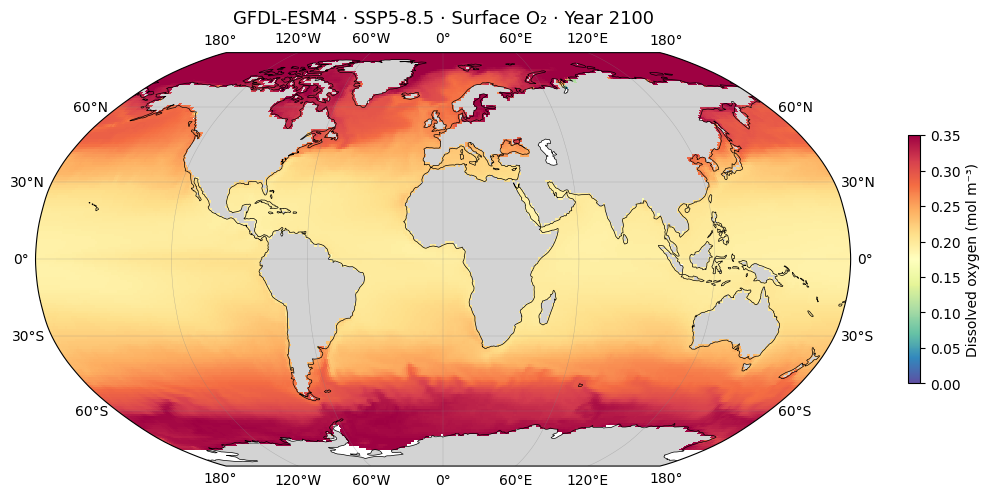

In [38]:
# Bring the surface slice into memory (.compute()) — only 180×360 floats
surface_o2_global = (
    ds["o2"]
    .isel(member_id=0, dcpp_init_year=0, time=-1, lev=0)
    .assign_coords(lon=(ds["o2"].lon + 180) % 360 - 180)
    .sortby("lon")
    .compute()
)

fig, ax = plt.subplots(
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.Robinson()},
)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)

img = ax.pcolormesh(
    surface_o2_global.lon,
    surface_o2_global.lat,
    surface_o2_global,
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",
    vmin=0,
    vmax=0.35,
)
plt.colorbar(img, ax=ax, label="Dissolved oxygen (mol m⁻³)", shrink=0.6, pad=0.05)
ax.set_title("GFDL-ESM4 · SSP5-8.5 · Surface O₂ · Year 2100", fontsize=13)
plt.tight_layout()
plt.show()

## 📈 Single-point time series (Aegean Sea)

We loaded seven datasets covering four unique models (GFDL-ESM4, NorESM2-LM, NorESM2-MM, NorCPM1), but have only examined one. Here we extract a **single-point time series** for GFDL-ESM4 at a fixed location in the central Aegean Sea, combining the historical run with the SSP5-8.5 projection into one continuous plot.

Subsetting to a single lat/lon point with `.sel()` before `.compute()` means Dask downloads only the relevant chunks — far cheaper than loading the full 3-D field.

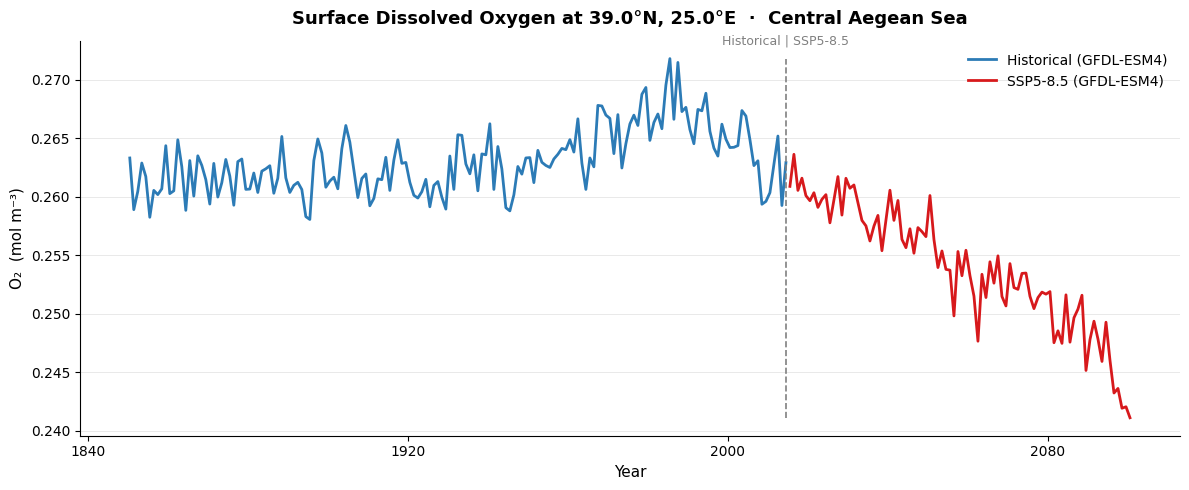

In [ ]:
# Single point in the central Aegean Sea
POINT_LAT = 39.0
POINT_LON = 25.0   # 0–360 convention (same as CMIP6 native)

# historical
ds_hist = dset_dict["CMIP.NOAA-GFDL.GFDL-ESM4.historical.Oyr.gr"]
o2_surf_hist = ds_hist["o2"].isel(member_id=0, dcpp_init_year=0, lev=0).chunk({"time": -1})
o2_point_hist = o2_surf_hist.sel(lat=POINT_LAT, lon=POINT_LON, method="nearest")

# SSP5-8.5 projection
o2_surf_for = ds["o2"].isel(member_id=0, dcpp_init_year=0, lev=0).chunk({"time": -1})
o2_point_for = o2_surf_for.sel(lat=POINT_LAT, lon=POINT_LON, method="nearest")

o2_hist_computed = o2_point_hist.compute()
o2_for_computed = o2_point_for.compute()

fig, ax = plt.subplots(figsize=(12, 5))

o2_hist_computed.plot(ax=ax, color="#2c7bb6", linewidth=2, label="Historical (GFDL-ESM4)")
o2_for_computed.plot(ax=ax, color="#d7191c", linewidth=2, label="SSP5-8.5 (GFDL-ESM4)")

ymin = min(float(o2_hist_computed.min()), float(o2_for_computed.min()))
ymax = max(float(o2_hist_computed.max()), float(o2_for_computed.max()))
split_t = o2_hist_computed.time.values[-1]
ax.vlines(split_t, ymin, ymax, linewidth=1.2, color="gray", linestyle="--", zorder=3)
ax.annotate(
    "Historical | SSP5-8.5",
    xy=(split_t, ymax),
    xytext=(0, 8),
    textcoords="offset points",
    color="gray",
    fontsize=9,
    va="bottom",
    ha="center",
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, color="lightgray", alpha=0.7, zorder=0)
ax.set_title(
    f"Surface Dissolved Oxygen at {POINT_LAT}°N, {POINT_LON}°E  ·  Central Aegean Sea",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_ylabel("O₂  (mol m⁻³)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


## ✏️ Exercises

### 🏋️ Exercise 1 — Different variable
Search for **sea surface temperature** (`tos`, table `Omon`) under `ssp585`. Load one model and plot a global map for the last time step.

```python
cat_tos = col.search(
    experiment_id='ssp585', table_id='Omon', variable_id='tos',
    grid_label='gr', member_id='r1i1p1f1'
)
# … your code here
```

### 🏋️ Exercise 2 — Depth profile
For the GFDL-ESM4 dataset, compare how dissolved oxygen varies with **depth** at a single ocean point (e.g. 35°N, 20°E) for years 2015 and 2100 on the same plot.

```python
# Hint: ds["o2"].isel(member_id=0, dcpp_init_year=0)
#             .sel(lat=35, lon=20, method='nearest')
#             .isel(time=0)   # 2015
# Note: lon is in 0-360 convention, so 20°E = 20.0
```

### 🏋️ Exercise 3 — Model spread
Extend the time series cell above into a multi-model loop: iterate over all models that have both `historical` and `ssp585` data (GFDL-ESM4, NorESM2-LM, NorESM2-MM), concatenate the two periods, and plot all three on the same axes. Then add a **shaded envelope** (min–max range across models) using `ax.fill_between()`. What does the inter-model spread tell you about projection uncertainty?